# Library Dependencies

In [2]:
import os
import numpy as np 
import pandas as pd 

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

In [4]:
# data visualization
import seaborn as sns 
import matplotlib.pyplot as plt 


# EDA

In [5]:
#path = '../dataset/covertype.csv'

In [6]:
columns = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am",
    "Hillshade_Noon",
    "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points",
]

columns += [f"Wilderness_Area{i}" for i in range(1, 5)]
columns += [f"Soil_Type{i}" for i in range(1, 41)]
columns += ["Cover_Type"]

df = pd.read_csv(
    "../dataset/covtype.data.gz",
    header=None,
    names=columns,
    compression="gzip"
)

df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [7]:
df.shape

(581012, 55)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-null  int64
 12 

In [9]:
df.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


- Terlihat pada kolom 1, 2, dan 3 terdapat kolom unnamed, biar tidak asal drop bisa coba di verifikasi di sumber datasetnya
- Terlihat juga ada 40 kolom yang sudah ter one-hot encoding dari awal, sehingga untuk explorasi perlu diperlakukan secara khusus untuk melihat impactnya.

## Check Value

In [10]:
df.isnull().sum()

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11                           0


In [11]:
df.duplicated().sum()

np.int64(0)

- Datanya tidak terdapat null values maupun duplicate, yang berarti tinggal kita cari outliernya saja

# Mengecek Distribusi Target

In [12]:
df["Cover_Type"].value_counts()

Cover_Type
2    283301
1    211840
3     35754
7     20510
6     17367
5      9493
4      2747
Name: count, dtype: int64

In [13]:
df["Cover_Type"].value_counts(normalize=True) * 100

Cover_Type
2    48.759922
1    36.460521
3     6.153746
7     3.530048
6     2.989095
5     1.633873
4     0.472796
Name: proportion, dtype: float64

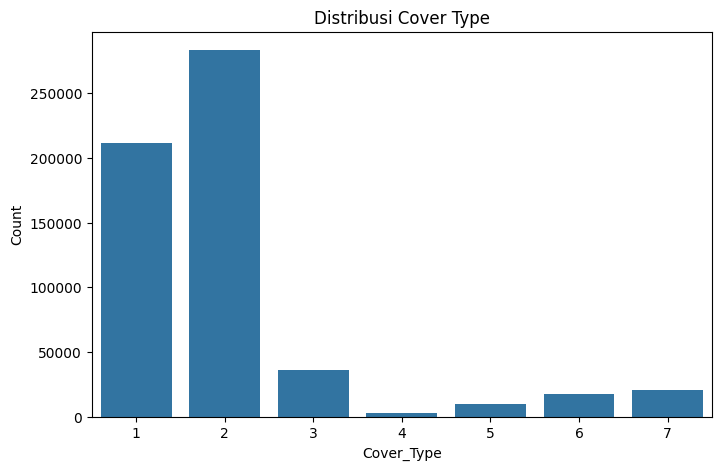

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="Cover_Type")
plt.title("Distribusi Cover Type")
plt.xlabel("Cover_Type")
plt.ylabel("Count")
plt.show()

- setelah dilakukan pengecekan distribusi, terlihat bahwa kelasnya cukup tidak seimbang, kelas 1 dan kelas 2 mendominasi.
- metric evaluasi accuracy tidak cukup, dibutuhkan untuk mengecek metric evaluasi lain.
- kemungkinan perlu dilakukan stratify atau metode penanganan lain untuk memastikan model tidak bias

# Finding Outlier

In [15]:
num_cols = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am",
    "Hillshade_Noon",
    "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]

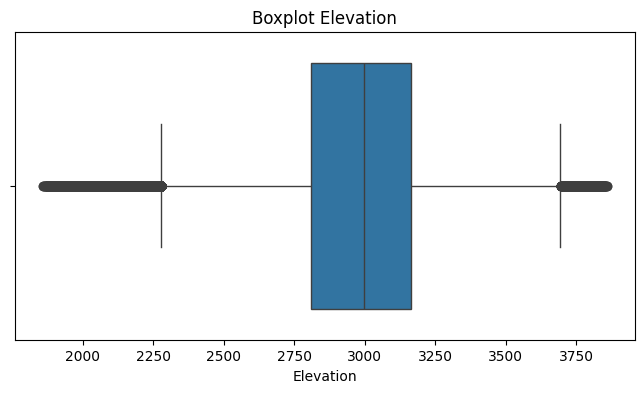

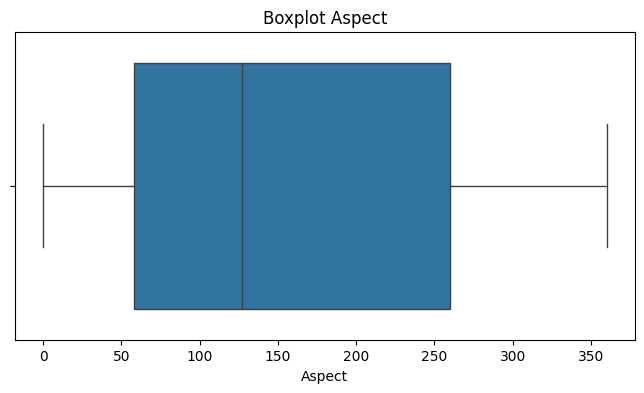

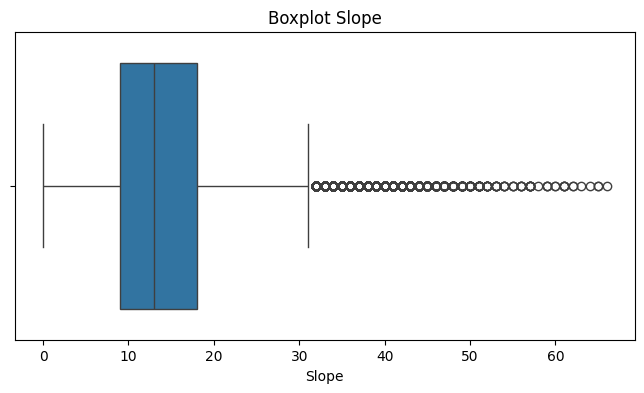

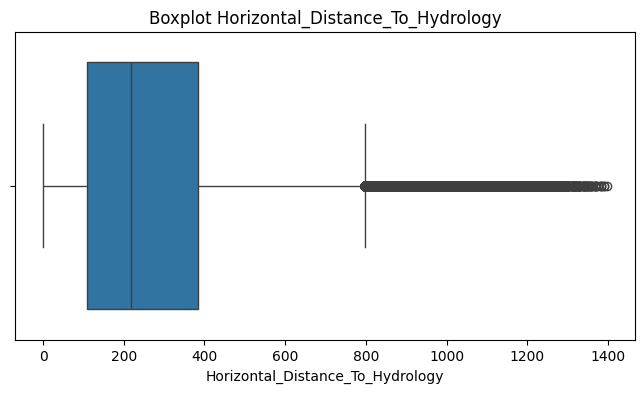

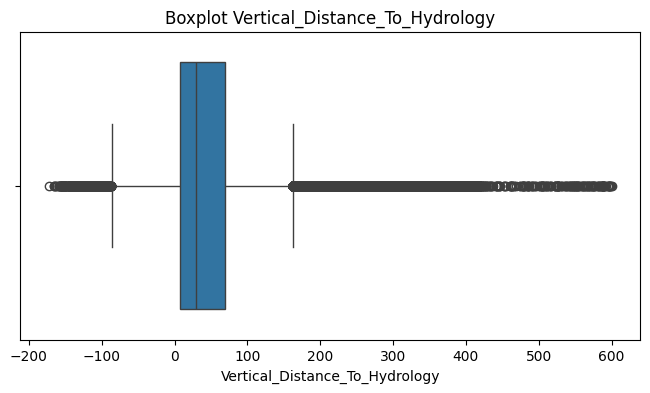

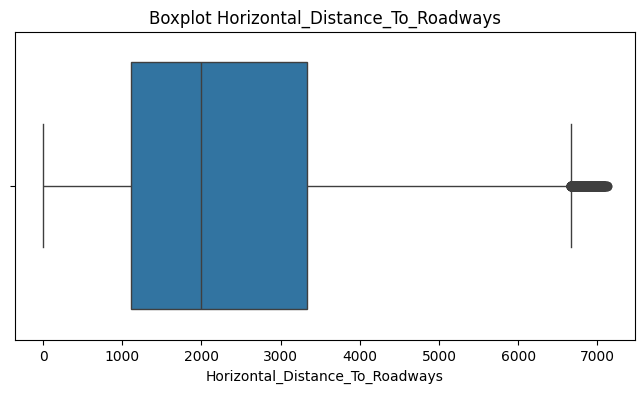

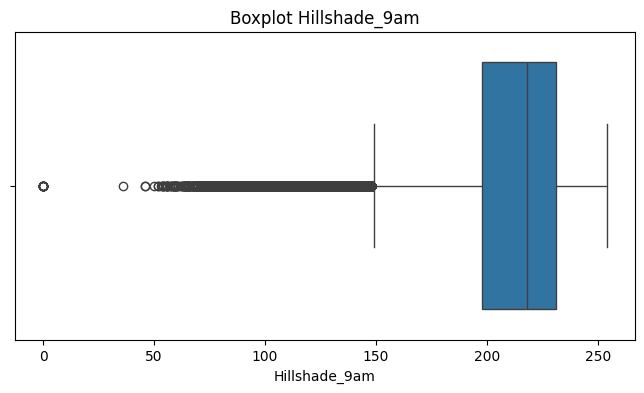

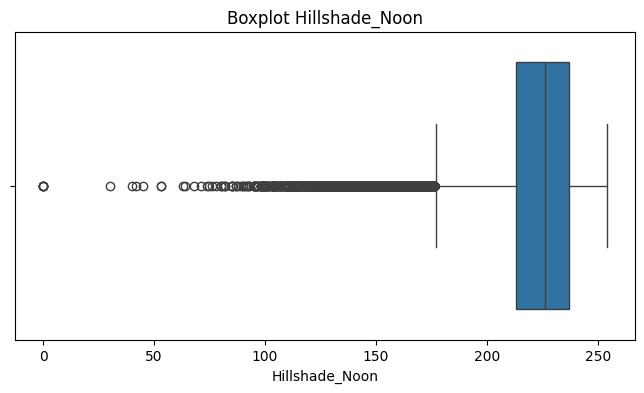

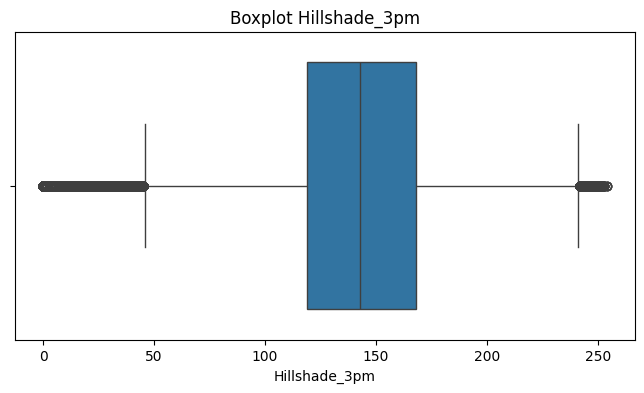

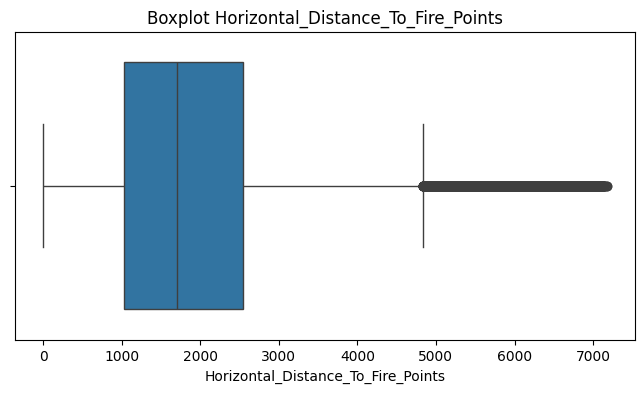

In [16]:
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot {col}")
    plt.xlabel(col)
    plt.show()

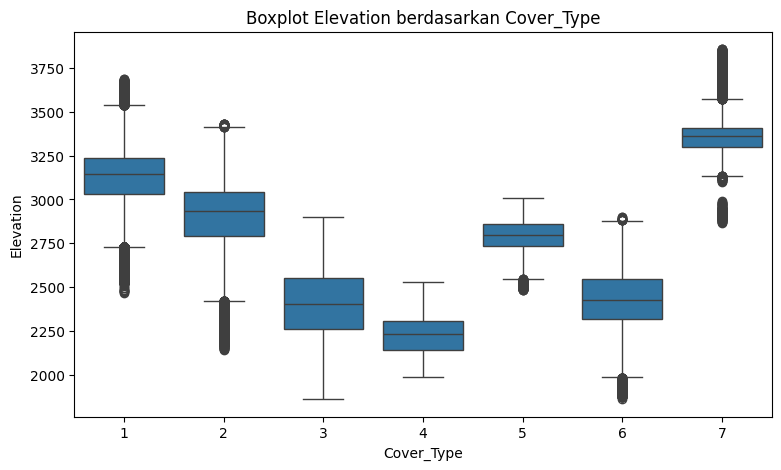

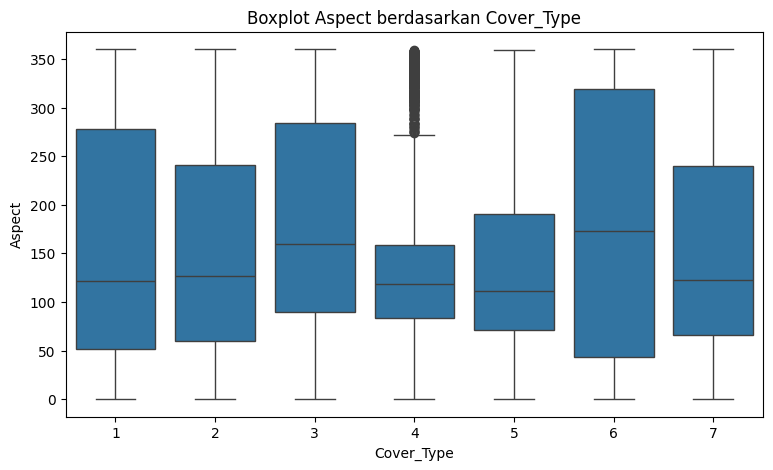

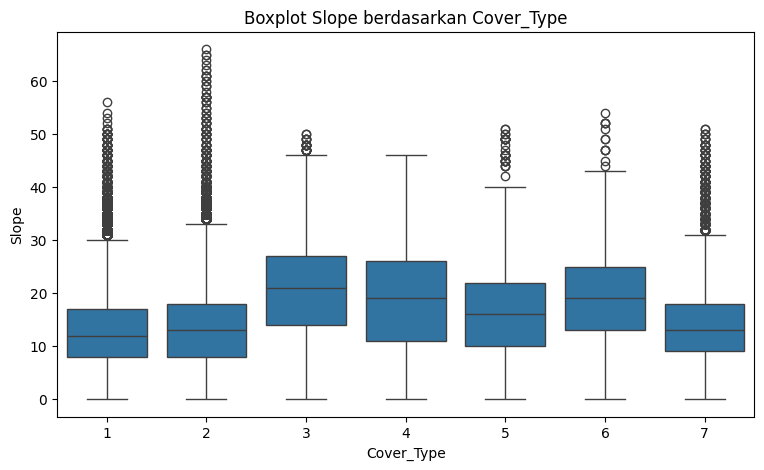

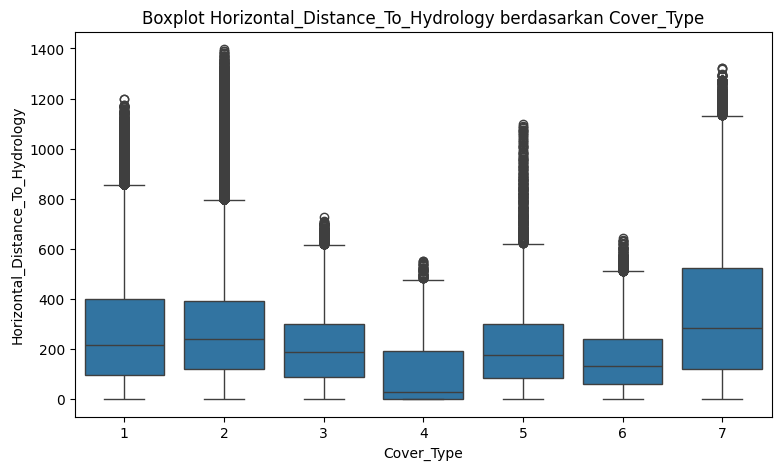

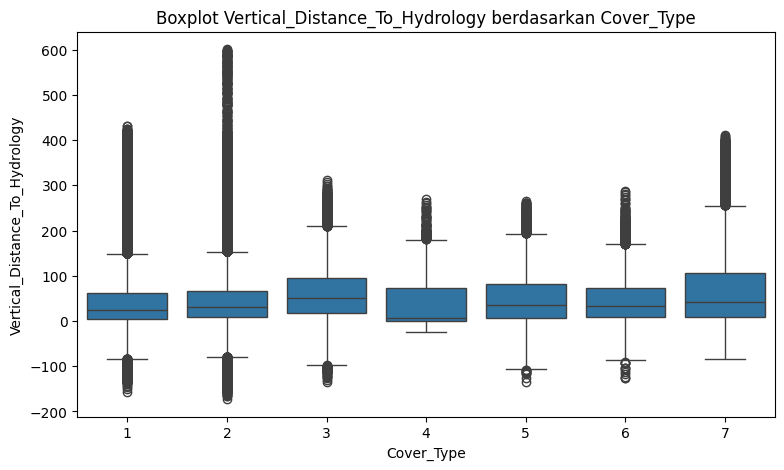

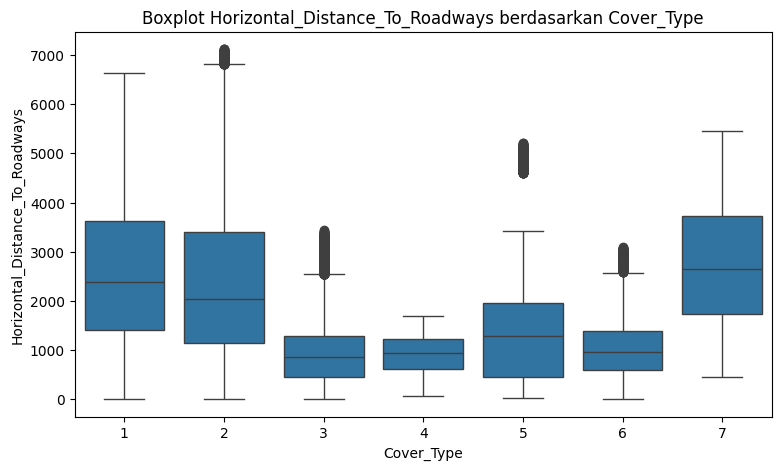

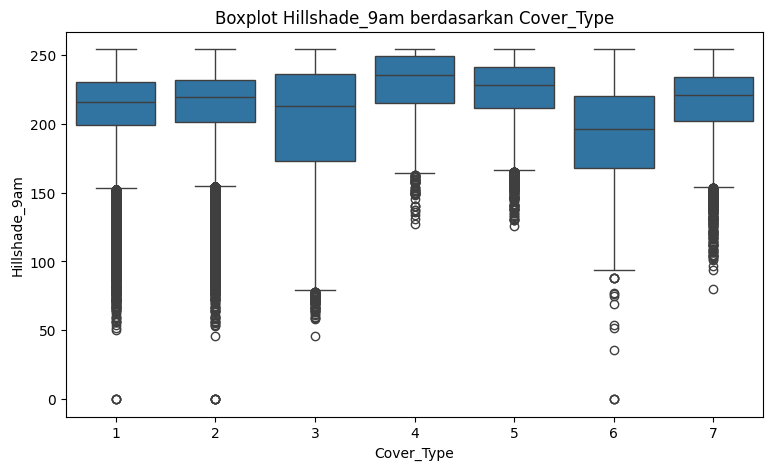

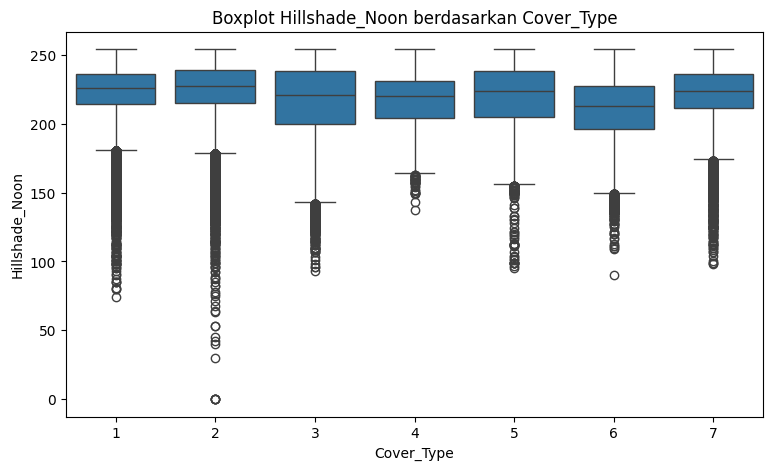

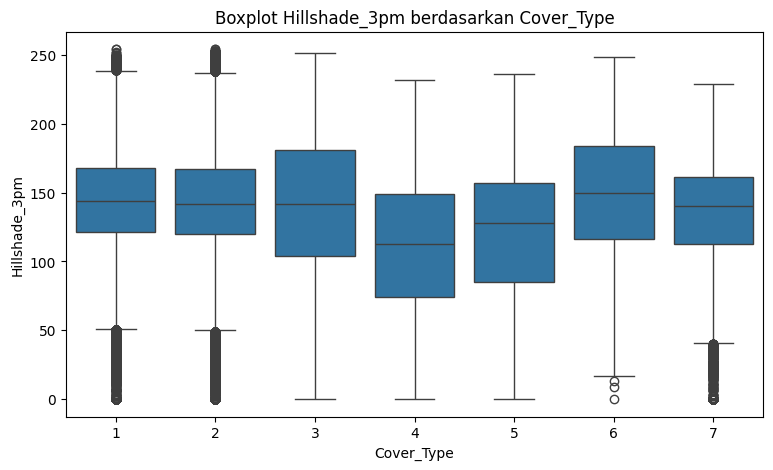

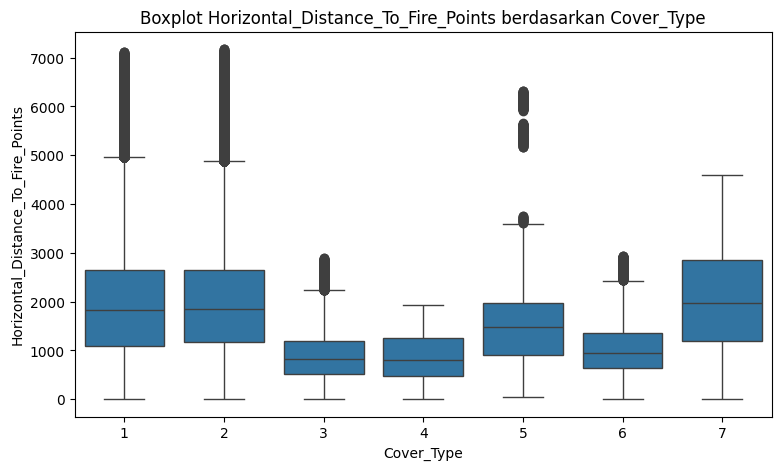

In [17]:
for col in num_cols:
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=df, x="Cover_Type", y=col)
    plt.title(f"Boxplot {col} berdasarkan Cover_Type")
    plt.xlabel("Cover_Type")
    plt.ylabel(col)
    plt.show()

In [18]:
outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_percentage = outlier_count / len(df) * 100

    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage": outlier_percentage
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df.sort_values(by="Outlier Percentage", ascending=False)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
4,Vertical_Distance_To_Hydrology,7.0,69.0,62.0,-86.0,162.0,31463,5.415207
9,Horizontal_Distance_To_Fire_Points,1024.0,2550.0,1526.0,-1265.0,4839.0,31157,5.362540
6,Hillshade_9am,198.0,231.0,33.0,148.5,280.5,17433,3.000454
7,Hillshade_Noon,213.0,237.0,24.0,177.0,273.0,15672,2.697363
0,Elevation,2809.0,3163.0,354.0,2278.0,3694.0,15569,2.679635
2,Slope,9.0,18.0,9.0,-4.5,31.5,15316,2.636090
3,Horizontal_Distance_To_Hydrology,108.0,384.0,276.0,-306.0,798.0,14557,2.505456
8,Hillshade_3pm,119.0,168.0,49.0,45.5,241.5,7832,1.347993
5,Horizontal_Distance_To_Roadways,1106.0,3328.0,2222.0,-2227.0,6661.0,669,0.115144
1,Aspect,58.0,260.0,202.0,-245.0,563.0,0,0.000000


Berdasarkan metode IQR, beberapa fitur numerik memiliki nilai ekstrem yang terdeteksi sebagai outlier. Namun, outlier tersebut tidak langsung dihapus karena nilai-nilainya masih berada dalam rentang yang valid berdasarkan konteks domain. Dataset Covertype merupakan data geografis mentah, sehingga nilai ekstrem dapat merepresentasikan variasi alami wilayah seperti elevasi tinggi, lereng curam, atau jarak yang jauh terhadap fitur geografis tertentu. Oleh karena itu, data outlier tetap dipertahankan pada baseline modeling.

Kami akan membandingkan beberapa skenario preprocessing untuk training model:
1. Baseline menggunakan data asli tanpa treatment outlier dan tanpa scaling
2. Capping outlier menggunakan metode IQR pada fitur numerik
3. Scaling pada fitur numerik
4. Capping Outlier + Scaling